Successfully injected boto3 credentials into environment.
Connecting to Icechunk repository at s3://airborne-smce-prod-user-bucket/JOIN/icechunk-stores/CEDA_Store_v3/...
Opening virtual dataset from Icechunk...
Sorting dataset by time to fix non-monotonic index...
Selecting SWE data for 2019-01-01...
Actually matched dataset time: 2019-01-01 00:00:00
Generating plot (this will fetch the byte-ranges from CEDA via HTTPS)...
Plot saved to swe_global_20190101.png


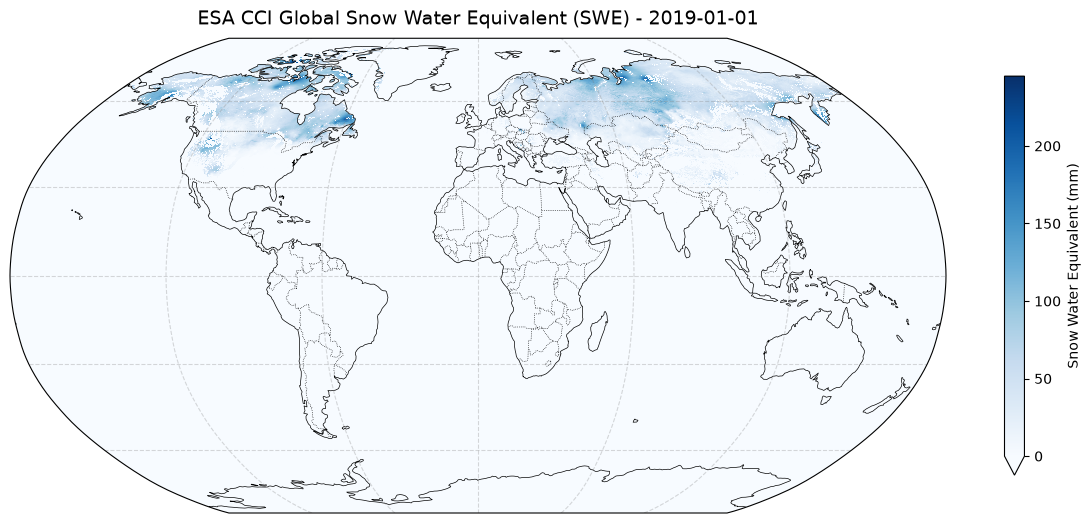

In [6]:
import os
import boto3
import icechunk
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def setup_aws_credentials():
    """Use boto3 to grab the working credentials and set them for obstore."""
    session = boto3.Session()
    creds = session.get_credentials()

    if creds:
        frozen_creds = creds.get_frozen_credentials()
        os.environ["AWS_ACCESS_KEY_ID"] = frozen_creds.access_key
        os.environ["AWS_SECRET_ACCESS_KEY"] = frozen_creds.secret_key
        if frozen_creds.token:
            os.environ["AWS_SESSION_TOKEN"] = frozen_creds.token
            
        os.environ["AWS_EC2_METADATA_DISABLED"] = "true"
        
        if session.region_name:
            os.environ["AWS_REGION"] = session.region_name
            
        print("Successfully injected boto3 credentials into environment.")
    else:
        print("Warning: boto3 could not find AWS credentials.")


if __name__ == "__main__":
    setup_aws_credentials()

    # ==========================================
    # 1. Configuration
    # ==========================================
    bucket = "airborne-smce-prod-user-bucket"
    prefix = "JOIN/icechunk-stores/CEDA_Store_v3/"
    base_ceda_url = "https://dap.ceda.ac.uk/neodc/esacci/snow/data/swe/MERGED/v4.0/"
    target_date = "2019-01-01"

    print(f"Connecting to Icechunk repository at s3://{bucket}/{prefix}...")

    # ==========================================
    # 2. Configure Icechunk Access (Read-Only)
    # ==========================================
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)

    config = icechunk.RepositoryConfig.default()
    container = icechunk.VirtualChunkContainer(
        name="ceda_archive",       
        url_prefix=base_ceda_url,  
        store=icechunk.http_store()
    )
    config.set_virtual_chunk_container(container)

    repo = icechunk.Repository.open(
        storage=storage,
        config=config,
        authorize_virtual_chunk_access={base_ceda_url: icechunk.credentials.HttpAccess}
    )

    session = repo.readonly_session("main")

    # ==========================================
    # 3. Read and Select the Data
    # ==========================================
    print("Opening virtual dataset from Icechunk...")
    ds = xr.open_zarr(session.store, zarr_format=3)

    # FIX: Sort the dataset by the time dimension to make the index strictly monotonic
    print("Sorting dataset by time to fix non-monotonic index...")
    ds = ds.sortby('time')

    print(f"Selecting SWE data for {target_date}...")
    # Now xarray's native selection will work perfectly and find the exact date
    swe_day = ds['swe'].sel(time=target_date, method='nearest').squeeze()
    
    # Verify the exact matched date
    actual_datetime = pd.to_datetime(swe_day.time.values)
    actual_date_str = actual_datetime.strftime('%Y-%m-%d')
    print(f"Actually matched dataset time: {actual_datetime}")

    # ==========================================
    # 4. Plot on a Global Map
    # ==========================================
    print("Generating plot (this will fetch the byte-ranges from CEDA via HTTPS)...")

    fig, ax = plt.subplots(
        figsize=(12, 6), 
        subplot_kw={'projection': ccrs.Robinson()}
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.gridlines(draw_labels=False, alpha=0.3, color='gray', linestyle='--')

    swe_plot = swe_day.plot(
        ax=ax, 
        transform=ccrs.PlateCarree(),
        cmap='Blues',           
        vmin=0,                 
        cbar_kwargs={
            'label': 'Snow Water Equivalent (mm)', 
            'shrink': 0.7, 
            'orientation': 'vertical'
        }
    )

    ax.set_title(f"ESA CCI Global Snow Water Equivalent (SWE) - {actual_date_str}", fontsize=14, pad=10)
    ax.set_global()  

    plt.tight_layout()

    date_str_flat = actual_date_str.replace("-", "")
    output_filename = f"swe_global_{date_str_flat}.png"
    
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_filename}")

    plt.show()